# Part 3: Isolation Forest — Finding Anomalous Customers
**⏱ This section takes approximately 30 minutes.**

---

## Scenario: Thursday — The Watch List

Sarah has segments (yesterday). Now she wants to find INDIVIDUAL customers who don't fit any segment — the unusual cases worth investigating.

This is anomaly detection. The customer success team gets a watch list. Each customer gets a quick look.

## How Isolation Forest works

The core insight is deceptively simple: **anomalies are easier to isolate than normal points**.

Picture a dart board. Most darts cluster around the bullseye (dense region). A few land near the edge (sparse region). If you draw random dividing lines across the board, you'll isolate the edge darts in just a few cuts — the clustered darts need many more cuts to separate out.

Isolation Forest formalises this into an algorithm:

**Step 1 — Build one isolation tree:**
1. Pick a random feature (e.g. `tenure_months`)
2. Pick a random split value within that feature's range (e.g. 28 months)
3. Assign each customer to left (≤ 28) or right (> 28)
4. Repeat recursively on each partition — different random feature, different random value
5. Stop when each customer sits alone in their own partition

**Step 2 — Record the path length:**  
Count how many splits it took to isolate each customer. This is their *path length* for this tree.

```
Dense region (normal customer):    needs ~12 splits   →   long path
Sparse region (anomalous customer): needs ~4 splits   →   short path
```

**Step 3 — Repeat 100 times:**  
Build 100 trees, each with different random splits. Average each customer's path length across all trees.

**Step 4 — Convert to a score:**  
The output of `score_samples()` runs from roughly −0.7 to 0:
- Score near **0** → long paths → customer sits in a dense (normal) region
- Score near **−0.7** → very short paths → customer is in a sparse (anomalous) region

---

**Why this beats Z-score in high dimensions:**

Z-score checks one feature at a time — it flags customers with extreme values on *individual* features. But many real anomalies are only unusual in *combinations*:

> A customer with `returns_per_purchase = 0.40` (high but not extreme alone) **and** `tenure_months = 72` (long-tenured) **and** `num_purchases_quarter = 0` (completely inactive this quarter). No single feature screams "anomaly" — but the combination is rare and suspicious.

Isolation Forest splits on random features across 100 trees, naturally surfacing these *multivariate* patterns that Z-score misses entirely. Extension 3 at the end of this notebook compares them directly.

**Practical reasons to reach for Isolation Forest first:**
- No assumptions about the distribution of your data
- Works well in high dimensions (17 features here)
- Scales to millions of rows efficiently
- Outputs a *continuous score* — you can re-threshold without retraining
- The default industry choice for tabular anomaly detection

**By the end of this notebook you will be able to:**
- Fit `IsolationForest` and produce anomaly scores per row
- Interpret what makes each anomaly anomalous
- Use the `contamination` parameter responsibly
- Decide which anomalies are worth a human's time

In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 4.5)

print("✅ Libraries loaded — IsolationForest ready")

✅ Libraries loaded — IsolationForest ready


## Step 1 — Setup (same preprocessing as NB 02 + 03)

In [2]:
df = pd.read_csv("data/northstar_customers.csv")
features = df.drop(columns=["customer_id", "churned"])

numeric_features = ["age", "tenure_months", "num_purchases_quarter",
                    "avg_monthly_spend_gbp", "returns_per_purchase",
                    "last_login_days_ago", "avg_review_polarity",
                    "support_tickets_quarter"]
categorical_features = ["region", "subscription_tier"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("scl", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
                      categorical_features),
])

X_processed = preprocessor.fit_transform(features)
print(f"Processed shape: {X_processed.shape}")

Processed shape: (10000, 17)


## Step 2 — Fit Isolation Forest

Two key parameters:
- **`n_estimators`** — number of trees (default 100; 100-200 is plenty)
- **`contamination`** — your prior on what fraction of the data is anomalous. Used only to set the threshold between "normal" and "anomalous" labels.

For NorthStar's customer base, let's set `contamination=0.05` — we expect about 5% of customers to be unusual.

In [3]:
iso = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42,
    n_jobs=-1,
)

labels = iso.fit_predict(X_processed)   # -1 = anomaly, +1 = normal
scores = iso.score_samples(X_processed) # raw score (lower = more anomalous)

# Counts
n_anomalies = (labels == -1).sum()
n_normal    = (labels == +1).sum()
print(f"Anomalies flagged: {n_anomalies}  ({n_anomalies / len(labels):.2%})")
print(f"Normal customers:  {n_normal}")
print()
print(f"Score range: [{scores.min():.3f}, {scores.max():.3f}]")
print(f"Median score: {np.median(scores):.3f}")

Anomalies flagged: 500  (5.00%)
Normal customers:  9500

Score range: [-0.616, -0.393]
Median score: -0.478


## ⏸️ Pause and Predict

Before running the model, predict:
- What fraction of NorthStar customers do you think will be genuinely unusual? Is 5% a reasonable prior, or too high/low?
- Which single feature do you expect to drive most anomalies on this dataset? (Hint: think about what makes a customer *genuinely* unusual — not just extreme on one dimension.)

*Your prediction:*

> *Sample:* 5% (~500 customers) is probably slightly generous for a mature customer base, but it's a reasonable starting point — we can always tighten the threshold operationally. The likely drivers are *combinations*: very high spend + very high returns; long tenure with zero purchases this quarter; 5+ support tickets in one quarter (a rare event). No single feature should dominate — that's precisely why Isolation Forest is more powerful than Z-score here.

## Step 3 — Score distribution

Plot the histogram of anomaly scores. The threshold (set by `contamination`) is the dashed line.

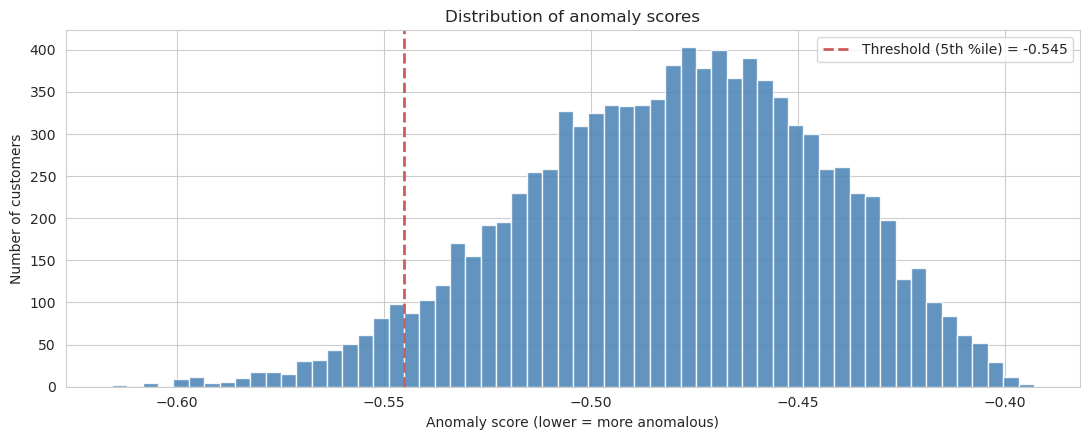

Customers below threshold (anomalies): 500
Customers at or above threshold:        9500


In [4]:
# Find the threshold IsolationForest used
threshold = np.percentile(scores, 5)  # contamination = 5% → 5th percentile

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(scores, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(threshold, color="indianred", linestyle="--", linewidth=2,
            label=f"Threshold (5th %ile) = {threshold:.3f}")
ax.set_xlabel("Anomaly score (lower = more anomalous)")
ax.set_ylabel("Number of customers")
ax.set_title("Distribution of anomaly scores")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Customers below threshold (anomalies): {(scores < threshold).sum()}")
print(f"Customers at or above threshold:        {(scores >= threshold).sum()}")

## Step 4 — Inspect the most anomalous customers

For the top-10 most anomalous, look at every feature and compare to the median. The features that diverge most tell you WHY they were flagged.

In [5]:
# Add score and label to the dataframe
df_results = features.copy()
df_results["anomaly_score"] = scores
df_results["is_anomaly"]    = (labels == -1)

# Get the 10 MOST anomalous customers
most_anomalous = df_results.nsmallest(10, "anomaly_score")

# Show with global median for comparison
print("Top 10 most anomalous customers:")
print(most_anomalous[numeric_features + ["anomaly_score"]].round(2).to_string())
print()
print("Global median for context:")
print(features[numeric_features].median().round(2).to_string())

Top 10 most anomalous customers:
      age  tenure_months  num_purchases_quarter  avg_monthly_spend_gbp  returns_per_purchase  last_login_days_ago  avg_review_polarity  support_tickets_quarter  anomaly_score
4803   67             18                      7                 438.01                  0.08                170.0                 0.01                        0          -0.62
3278   80              3                      3                  37.96                  0.41                173.0                 0.55                        3          -0.61
8905   59             58                      7                 318.23                  0.45                  8.0                 0.76                        2          -0.61
9155   22             49                      7                 429.53                  0.26                 66.0                -0.58                        1          -0.61
71     29             14                      5                 267.17                  0.10

### 💡 What makes them anomalous?

The table above lists the 10 customers with the lowest anomaly scores. The global medians are printed below — use them as your "normal" baseline.

**How to read the table:**

For each row, scan across the features and ask: *how far is this value from the median?* A value 3–5× the median (or near zero when the median is non-zero) is a red flag.

Then try to connect the dots into a story.

**Step-by-step:**
1. Find the row with the **lowest anomaly_score** (most anomalous customer)
2. Identify the 2–3 features furthest from the median
3. Write a one-sentence hypothesis: *"This customer is unusual because..."*

**Common patterns to look for:**

| Pattern | Features involved | Likely story |
|---|---|---|
| High tenure + near-zero purchases + high support tickets | `tenure_months` ↑, `num_purchases_quarter` ≈ 0, `support_tickets_quarter` ↑ | Long-term customer who stopped buying and started complaining — possible pre-churn signal, worth a personal call |
| Very high spend + very high returns | `avg_monthly_spend_gbp` ↑↑, `returns_per_purchase` ↑↑ | Buys a lot, returns most of it — possible reseller, buy-and-return habit, or product fit issue |
| Long inactive + low review polarity | `last_login_days_ago` ↑↑, `avg_review_polarity` ↓ | Silent unhappy customer — left negative reviews, then disappeared |
| Any combination of extreme values | Multiple features simultaneously off-median | Multivariate outlier — this is exactly what Z-score would have missed |

**This is the value of anomaly detection.** The model can only say *which* customers are unusual. *Why* they're unusual — and what to do about it — requires domain knowledge. The model surfaces; the human investigates.

## Step 5 — Compare anomaly scores to the segments from NB 03

Are anomalies concentrated in ONE segment? Or spread across all of them?

In [6]:
from sklearn.cluster import KMeans

# Re-run K-Means to get the cluster labels from NB 03
km = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_processed)

df_results["cluster"] = cluster_labels

# Anomaly rate per cluster
anomaly_by_cluster = df_results.groupby("cluster").agg(
    n_customers=("is_anomaly", "size"),
    n_anomalies=("is_anomaly", "sum"),
)
anomaly_by_cluster["anomaly_rate"] = (
    anomaly_by_cluster["n_anomalies"] / anomaly_by_cluster["n_customers"]
)
print("Anomalies per cluster:")
print(anomaly_by_cluster.to_string(float_format=lambda x: f"{x:.3f}"))

Anomalies per cluster:
         n_customers  n_anomalies  anomaly_rate
cluster                                        
0               3463          105         0.030
1               1138          158         0.139
2               3540           92         0.026
3               1859          145         0.078


### 💡 What this tells us

- **Anomalies are spread across all clusters.** That confirms anomaly detection is finding genuinely UNUSUAL customers — not just the edge cases of one underrepresented segment. If anomalies clustered in one segment, they'd just be that segment's fringe members, not true outliers.

- **Some clusters have higher anomaly rates than others.** Look at the `anomaly_rate` column. Cross-reference with the named segments from NB 03:

| Cluster | Name | Key signal |
|---|---|---|
| 0 | **Loyal Veterans** | Long tenure, recently active, low returns |
| 1 | **Dormant / At-Risk** | Very long since last login |
| 2 | **New Actives** | Short tenure, recently active, few returns |
| 3 | **Serial Returners** | Extreme return rate |

- **Expect Cluster 3 ("Serial Returners") to have a higher anomaly rate** — extreme return behaviour is one of the strongest isolation signals in this dataset.
- **Cluster 1 ("Dormant / At-Risk") anomalies are doubly urgent** — they're both silently churning AND unusual in other ways.

---

**What the business should do with the watch list:**

The anomaly list is not a homogeneous queue. Different anomaly types need different responses — routing the right customer to the right team is what makes the list actionable:

| Anomaly type | Key features | Who acts | Action |
|---|---|---|---|
| Long-tenured, suddenly inactive, complaining | `tenure_months` ↑, `num_purchases` ≈ 0, `support_tickets` ↑ | Customer Success | Personal outreach — understand the complaint, offer resolution |
| High spend + high returns | `avg_monthly_spend_gbp` ↑↑, `returns_per_purchase` ↑↑ | Operations / Fraud | Investigate for buy-return abuse or product fit problems |
| Long inactive + negative reviews | `last_login_days_ago` ↑↑, `avg_review_polarity` ↓ | Marketing | Win-back campaign — understand what drove them away |
| New customer with extreme behaviour | Short `tenure_months` + any extreme feature | Product | Check for onboarding failure or data quality issue |

**A raw list of 500 customer IDs is hard to act on. A list with a one-line reason per customer — sorted by anomaly score, flagged by pattern — is immediately useful.** That's the translation from model output to business value.

**Final Friday deliverable:** segment summary (NB 03) + triaged anomaly watch list (NB 04). The customer success team knows who to call and why.

## ✅ Section Summary

| Step | Result |
|---|---|
| **Fit Isolation Forest** | One line of code; 100 trees |
| **Anomaly score per customer** | Continuous; can re-threshold |
| **5% flagged as anomalies** | About 500 customers from 10,000 |
| **Profiled the most anomalous** | Each one has its own "why" — feature combinations, not single-feature extremes |
| **Cross-checked with clusters** | Anomalies appear across all segments — they're genuinely unusual, not just a minority cluster |
| **Business routing** | Different anomaly types → different teams: retention, fraud, marketing, product |

**Key insight:**
> Isolation Forest finds *which* customers are unusual. *Why* they're unusual is a human's job. The model surfaces; the human investigates and routes.

---

## 🏁 Friday — What Sarah Presents

Sarah walks into Marcus's office with three artefacts:

| # | Deliverable | Tool |
|---|---|---|
| 1 | **2D PCA visualisation** of the customer base | PCA (NB 02) |
| 2 | **4 customer segments** named and profiled | K-Means (NB 03) |
| 3 | **Watch list of ~500 anomalous customers** — triaged by anomaly type | Isolation Forest (NB 04) |

Marcus nods. *"Good. Now — sales are seasonal. Can you forecast next quarter's revenue?"*

That question — **time-ordered data forecasting** — is the engine of **L06 (Time Series Forecasting).**

---
**Next step →** Open `assignment.ipynb` for the after-class exercises.

*Or, for deeper material on hierarchical clustering, DBSCAN, and UMAP visualisation: open `optional_extensions.ipynb`.*

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## Extension 1 — The `contamination` parameter — what changes if you change it?

`contamination` only sets the threshold for the binary label. The continuous `score_samples()` is unchanged. Demo: refit with three different contamination values and see what happens to the flagged set.

In [7]:
for c in [0.01, 0.05, 0.10]:
    iso_c = IsolationForest(n_estimators=100, contamination=c, random_state=42, n_jobs=-1)
    iso_c.fit(X_processed)
    n_flagged = (iso_c.predict(X_processed) == -1).sum()
    print(f"contamination={c}:  flagged = {n_flagged}  ({n_flagged/len(X_processed):.2%})")
print()
print("→ contamination directly controls how strict the threshold is.")
print("→ For unknown ground truth, start conservative (1-2%) and widen if needed.")

contamination=0.01:  flagged = 100  (1.00%)
contamination=0.05:  flagged = 500  (5.00%)
contamination=0.1:  flagged = 1000  (10.00%)

→ contamination directly controls how strict the threshold is.
→ For unknown ground truth, start conservative (1-2%) and widen if needed.


## Extension 2 — Score-based scoring with a custom threshold

Instead of using `contamination`, you can use the continuous `score_samples` output and pick your own threshold based on operational constraints.

In [9]:
# Scenario: the customer success team can review 100 customers a week.
n_to_review = 100

# Pick the threshold so exactly the bottom 100 customers are flagged
sorted_scores = np.sort(scores)
custom_threshold = sorted_scores[n_to_review - 1]

# Apply
custom_flagged = scores <= custom_threshold

print(f"Custom threshold (top {n_to_review} most anomalous): {custom_threshold:.3f}")
print(f"Number flagged: {custom_flagged.sum()}")
print()

# What's the overlap with the contamination-based labels?
default_flagged = labels == -1
overlap = (custom_flagged & default_flagged).sum()
print(f"Overlap with contamination=0.05 labels: {overlap}/{n_to_review}")
print()
print("→ The score is what matters operationally. Pick the threshold for your team's capacity.")

Custom threshold (top 100 most anomalous): -0.571
Number flagged: 100

Overlap with contamination=0.05 labels: 100/100

→ The score is what matters operationally. Pick the threshold for your team's capacity.


## Extension 3 — Compare Isolation Forest to Z-score outliers (single-feature)

A naive approach: flag anyone with |z| > 3 on any feature. This catches univariate outliers but misses multivariate ones.

In [10]:
# Z-score on the original numeric features
from sklearn.preprocessing import StandardScaler

X_num = features[numeric_features].fillna(features[numeric_features].median())
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# Flag if ANY feature has |z| > 3
z_outliers = (np.abs(X_num_scaled) > 3).any(axis=1)

# Compare
df_results["z_outlier"] = z_outliers

both = (df_results["is_anomaly"] & df_results["z_outlier"]).sum()
only_iso = (df_results["is_anomaly"] & ~df_results["z_outlier"]).sum()
only_z = (~df_results["is_anomaly"] & df_results["z_outlier"]).sum()

print(f"Flagged by BOTH Isolation Forest AND |z|>3:  {both}")
print(f"Flagged by Isolation Forest only (multivariate): {only_iso}")
print(f"Flagged by |z|>3 only (single-feature extremes): {only_z}")
print()
print("→ Isolation Forest catches MULTIVARIATE anomalies that |z| misses.")
print("→ |z| catches single-feature extremes that Isolation Forest might miss if the rest of the row looks normal.")
print("→ For best coverage, use BOTH (and review the union).")

Flagged by BOTH Isolation Forest AND |z|>3:  199
Flagged by Isolation Forest only (multivariate): 301
Flagged by |z|>3 only (single-feature extremes): 470

→ Isolation Forest catches MULTIVARIATE anomalies that |z| misses.
→ |z| catches single-feature extremes that Isolation Forest might miss if the rest of the row looks normal.
→ For best coverage, use BOTH (and review the union).
